In [2]:
import xarray as xr
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy
from mpl_toolkits.axes_grid1 import make_axes_locatable
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'POSTPROCESSING')))
from ETC_tools import open_files
import numpy as np
from scipy.stats import gaussian_kde
from scipy.ndimage import gaussian_filter
import cmocean
import matplotlib.colors as mcolors
import matplotlib

In [3]:
simulations = ['ERA5']
future = True #1979 is not taken into account, which is also not taken into account in the contribution pickle file
test = ['raw', '01mmh']
per_type = ['all-day', 'wet-day']
test_trad = {'raw':'all-day', '01mmh':'wet-day'}
EETC_dict = {}
df = {}

for itest in test:
    df_test, EETC_dict_test = open_files(simulations[0], test=itest, future=True, ref=False)
    
    EETC_dict[test_trad[itest]] = EETC_dict_test
    df[test_trad[itest]] = df_test

In [4]:
quantile_target = 0.99
count_per_category = {}

for category in EETC_dict:
    storms = EETC_dict[category]
    count_positive = 0
    for storm_id, storm_data in storms.items():
        value = storm_data['cum_precip'].sel(quantile=quantile_target).item()
        if value > 0:
            count_positive += 1
    count_per_category[category] = count_positive

print(count_per_category)

{'all-day': 3932, 'wet-day': 2709}


In [13]:
file_path_raw = '/home/vdemeyer/projects/rrg-gachon/vdemeyer/CONTRIB/contribution_ETCs_1005hPa_ERA5_pr.pkl'
file_path2_01mmh = '/home/vdemeyer/projects/rrg-gachon/vdemeyer/CONTRIB/contribution_ETCs_1005hPa_ERA5_pr_01mmh.pkl'

with open(file_path_raw, 'rb') as file:
    data_raw = pickle.load(file)

with open(file_path2_01mmh, 'rb') as file:
    data_01mmh = pickle.load(file)

data = {}
for key in data_raw.keys():
    data[key] = {
        "all-day": data_raw[key],
        "wet-day": data_01mmh[key]
    }

# Density calculation

In [14]:
count_total = {}
count_seasonal = {}
start = f"1980-01-01 00:00:00"
sim = 'ERA5'

for iper in per_type:
    if sim == 'ERA5':
        end = f"2023-08-31 23:00:00"
    elif sim == 'UBB':
        end = f"2023-12-31 23:00:00"
    else:
        end = f"2014-12-31 23:00:00"

    expected_time = pd.date_range(
        start=start,
        end=end,
        freq="h"
    ).to_numpy()
    
    seasons = {
        'DJF': [12, 1, 2],
        'MAM': [3, 4, 5],
        'JJA': [6, 7, 8],
        'SON': [9, 10, 11]
    }
    
    count_total[iper] = len(expected_time)
    count_seasonal[iper] = {}
    
    for season, months in seasons.items():
        season_time = [t for t in expected_time if t.astype('datetime64[M]').item().month in months]
        count_seasonal[iper][season] = len(season_time)
    
data['count_total_steps'] = count_total
data['count_seasonal_steps'] = count_seasonal

In [15]:
#Calcul de la densité sur des points de grille de 5°
lat_bins = np.arange(-90, 91, 5)
lon_bins = np.arange(-180, 181, 5)
lat_centers = (lat_bins[:-1] + lat_bins[1:]) / 2
lon_centers = (lon_bins[:-1] + lon_bins[1:]) / 2

density_dict = {}

for sim_name, sim_df in df.items():
    hist2d, _, _ = np.histogram2d(sim_df['lat'], sim_df['lon'], bins=[lat_bins, lon_bins])
    hist2d_norm = (hist2d / data['count_total_steps'][sim_name]) * 100.
    # hist2d_smooth = gaussian_filter(hist2d_norm, sigma=0.2)
    
    density_dict[sim_name] = hist2d_norm

sim_names = list(density_dict.keys())
density_array = np.stack([density_dict[sim] for sim in sim_names], axis=0)

da_density = xr.DataArray(
    density_array,
    dims=("percentile_type", "lat", "lon"),
    coords={"percentile_type": per_type, "lat": lat_centers, "lon": lon_centers},
    name="cyclone_density_normalized"
)

In [16]:
quantiles = [0.98, 0.99, 0.995, 0.999]

EETCs_list = {}

for iper in per_type:
    EETCs_list[iper] = {
        'precip': {str(q): [] for q in quantiles},
    }

    for storm in EETC_dict[iper]:
        for quantile in quantiles:
            q_str = str(quantile)
            storm_data = EETC_dict[iper][storm]
            
            if (
                storm_data['cum_precip'].sel(quantile=quantile).values != 0 or
                storm_data['cum_avg_precip'].sel(quantile=quantile).values != 0
            ):
                EETCs_list[iper]['precip'][q_str].append(storm)

In [17]:
# Quantiles considérés
quantiles = [0.98, 0.99, 0.995, 0.999]

# Grilles en latitude et longitude (par exemple, 5° de bin)
lat_bins = np.arange(-90, 91, 5)
lon_bins = np.arange(-180, 181, 5)
lat_centers = (lat_bins[:-1] + lat_bins[1:]) / 2
lon_centers = (lon_bins[:-1] + lon_bins[1:]) / 2

# On initialise le dictionnaire principal pour stocker uniquement les histogrammes précip
density_filtered = {'precip': {}}

# Parcours des simulations
for sim_name, sim_df in df.items():
    for q in quantiles:
        q_str = str(q)

        # Récupération des ID de tempêtes pour les précipitations
        precip_storms = set(EETCs_list[sim_name]['precip'][q_str])

        # Filtrage
        filtered = sim_df[sim_df['storm'].isin(precip_storms)]

        # Histogramme 2D
        if sim_name not in density_filtered['precip']:
            density_filtered['precip'][sim_name] = []
        hist2d, _, _ = np.histogram2d(
            filtered['lat'], filtered['lon'],
            bins=[lat_bins, lon_bins]
        )
        hist2d_norm = (hist2d / data['count_total_steps'][sim_name]) * 100.
        density_filtered['precip'][sim_name].append(hist2d_norm)

# Conversion en DataArray
density_arrays = {}

sim_names = list(density_filtered['precip'].keys())
data_stack = []
for sim in sim_names:
    arr = np.stack(density_filtered['precip'][sim], axis=0)
    data_stack.append(arr)

final_array = np.stack(data_stack, axis=0)
density_arrays['precip'] = xr.DataArray(
    final_array,
    dims=("percentile_type", "quantile", "lat", "lon"),
    coords={
        "percentile_type": per_type,
        "quantile": quantiles,
        "lat": lat_centers,
        "lon": lon_centers
    },
    name="cyclone_density_precip"
)

# Map plots

## Function to plot the maps

In [18]:
for_pole = xr.open_dataset('/home/vdemeyer/projects/rrg-gachon/vdemeyer/UBB/PR/pr_ubb_199102_se.nc')
pole_lon = for_pole.rotated_pole.attrs['grid_north_pole_longitude']
pole_lat = for_pole.rotated_pole.attrs['grid_north_pole_latitude']
polecrs = ccrs.RotatedPole(pole_longitude=pole_lon, pole_latitude=pole_lat)

positions = [
    [0.05, 0.18, 0.48, 0.50],  # Rangée du haut, Colonne 1
    [0.55, 0.18, 0.48, 0.50],  # Rangée du haut, Colonne 2
]

def get_colormap(colormap_name):
    # Si l'entrée est déjà une colormap (comme cmocean.cm.curl)
    if hasattr(colormap_name, '__call__'):
        return colormap_name
    
    # Sinon, essaie de la récupérer parmi les colormaps enregistrées (matplotlib ou ajoutées comme cmocean)
    try:
        return plt.get_cmap(colormap_name)
    except ValueError:
        raise ValueError(f"Colormap '{colormap_name}' not found.")
        

def plot_map(contrib, colormap, vmin, vmax, label, style='pcolormesh', contour_levels=None, fmt=None, cont=None, sigma=None, step=None, ting=False, **kwargs):
    plotcrs = ccrs.LambertConformal(central_latitude=45, central_longitude=-95)
    fig = plt.figure(figsize=(18, 25))
    axes = [fig.add_axes(pos, projection=plotcrs) for pos in positions]
        
    if vmin < 0:
        extend_opt = 'both'
    elif vmax < 100:
        extend_opt = 'max'
    else:
        extend_opt = 'neither' 
        
    if colormap == 'Spectral_r':
        spectral = matplotlib.colormaps['Spectral_r']
        colors = spectral(np.linspace(0, 1, 256))
        colors[128:145] = colors[128:145] * 0.85  # Reduce brightness at the center
        cmap = mcolors.LinearSegmentedColormap.from_list('ModifiedSpectral', colors)
    else:
        cmap = get_colormap(colormap)
        
    for i, (ax, sim) in enumerate(zip(axes, contrib.keys())):
        var_lat = 'latitude'
        var_lon = 'longitude'
        crs = ccrs.PlateCarree()

        ax.set_extent([-130, -51, 77, 13], crs=ccrs.PlateCarree())
        borders = cartopy.feature.NaturalEarthFeature(category='cultural', name='admin_0_boundary_lines_land', scale='50m', facecolor='none')
        states_provinces = cartopy.feature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces', scale='50m', facecolor='none')
        lakes_color = cartopy.feature.NaturalEarthFeature(category='physical', name='lakes', scale='50m', facecolor='#7FB4D8', edgecolor='black')
        lakes_edge = cartopy.feature.NaturalEarthFeature(category='physical', name='lakes', scale='50m', facecolor='none', edgecolor='black')
        img = plt.imread('/home/vdemeyer/TOOLS/NE1_50M_SR_W.tif')
        ax.add_feature(borders, linewidth=0.5, edgecolor='black', zorder=2)
        ax.add_feature(states_provinces, edgecolor='black', linewidth=0.3)
        ax.add_feature(lakes_color, zorder=1, linewidth=0.3)
        ax.add_feature(lakes_edge, zorder=2, linewidth=0.3)
        ax.coastlines(resolution='10m', linewidth=0.4, color='black')
        ax.gridlines(linewidth=0.5, linestyle='--', color='k', alpha=0.25, xlocs=range(-180,180,10), ylocs=range(-90,90,10))
        ax.imshow(img, origin='upper', extent=(-180, 180, -90, 90), transform=ccrs.PlateCarree())


        if style == 'pcolormesh':
            sc = ax.pcolormesh(
                contrib[sim][var_lon], contrib[sim][var_lat], contrib[sim],
                transform=crs, cmap=cmap, vmin=vmin, vmax=vmax, shading='auto'
            )
        else:
            if vmin < 0:
                absmax = max(abs(vmin), abs(vmax))
                nice_max = int(np.ceil(absmax / step)) * step  # ou /10 si tu veux plus espacé\
                vmin = -nice_max
                vmax = +nice_max
                
            if ting == True:
                levels = [0.5, 2, 5] + list(np.arange(10, vmax + step, step))
            else:
                levels = np.arange(vmin, vmax + step, step)
            
            sc = ax.contourf(
                contrib[sim][var_lon], contrib[sim][var_lat], contrib[sim],
                transform=crs, levels=levels, cmap=cmap, vmin=vmin, vmax=vmax, extend=extend_opt
            )

        if cont is not None:
            if sigma is not None:

                # Lissage avec un filtre gaussien
                cont_smooth = xr.DataArray(
                    gaussian_filter(cont[sim].fillna(0), sigma=sigma),  # sigma contrôle l'intensité du lissage
                    coords=cont[sim].coords,
                    dims=cont[sim].dims,
                )

                contours = ax.contour(
                    cont_smooth.lon,
                    cont_smooth.lat,
                    cont_smooth,
                    levels=contour_levels,
                    colors='k',
                    linewidths=2,
                    alpha=0.9,
                    transform=ccrs.PlateCarree(),
                )
            else:
                contours = ax.contour(
                    cont[sim].lon,
                    cont[sim].lat,
                    cont[sim],
                    levels=contour_levels,
                    colors='k',
                    linewidths=2,
                    alpha=0.9,
                    transform=ccrs.PlateCarree(),
                )
            ax.clabel(contours, inline=True, fontsize=10, fmt=fmt)
            
        ax.text(0.98, 0.98, sim, transform=ax.transAxes, fontsize=17, fontweight='bold',
                ha='right', va='top', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.2'))
        
        # ax.contour(
        #     Mask_NNA['rlon'],
        #     Mask_NNA['rlat'],
        #     Mask_NNA,
        #     levels=[0.99],
        #     linewidths=3,
        #     colors='black',
        #     alpha=0.75,
        #     transform=polecrs,
        # )
        
    cbar_ax = fig.add_axes([0.15, 0.23, 0.8, 0.035])
    if style == 'pcolormesh':
        cbar = fig.colorbar(sc, cax=cbar_ax, orientation="horizontal", pad=0.02, extend=extend_opt)
    else:
        int_levels = [l if l == 0.5 else int(l) for l in levels]
        cbar = fig.colorbar(sc, cax=cbar_ax, orientation="horizontal", pad=0.02)
        cbar.ax.set_xticklabels(int_levels)
    cbar.set_label(label, fontsize=18)
    cbar.ax.tick_params(labelsize=18)

## Density maps

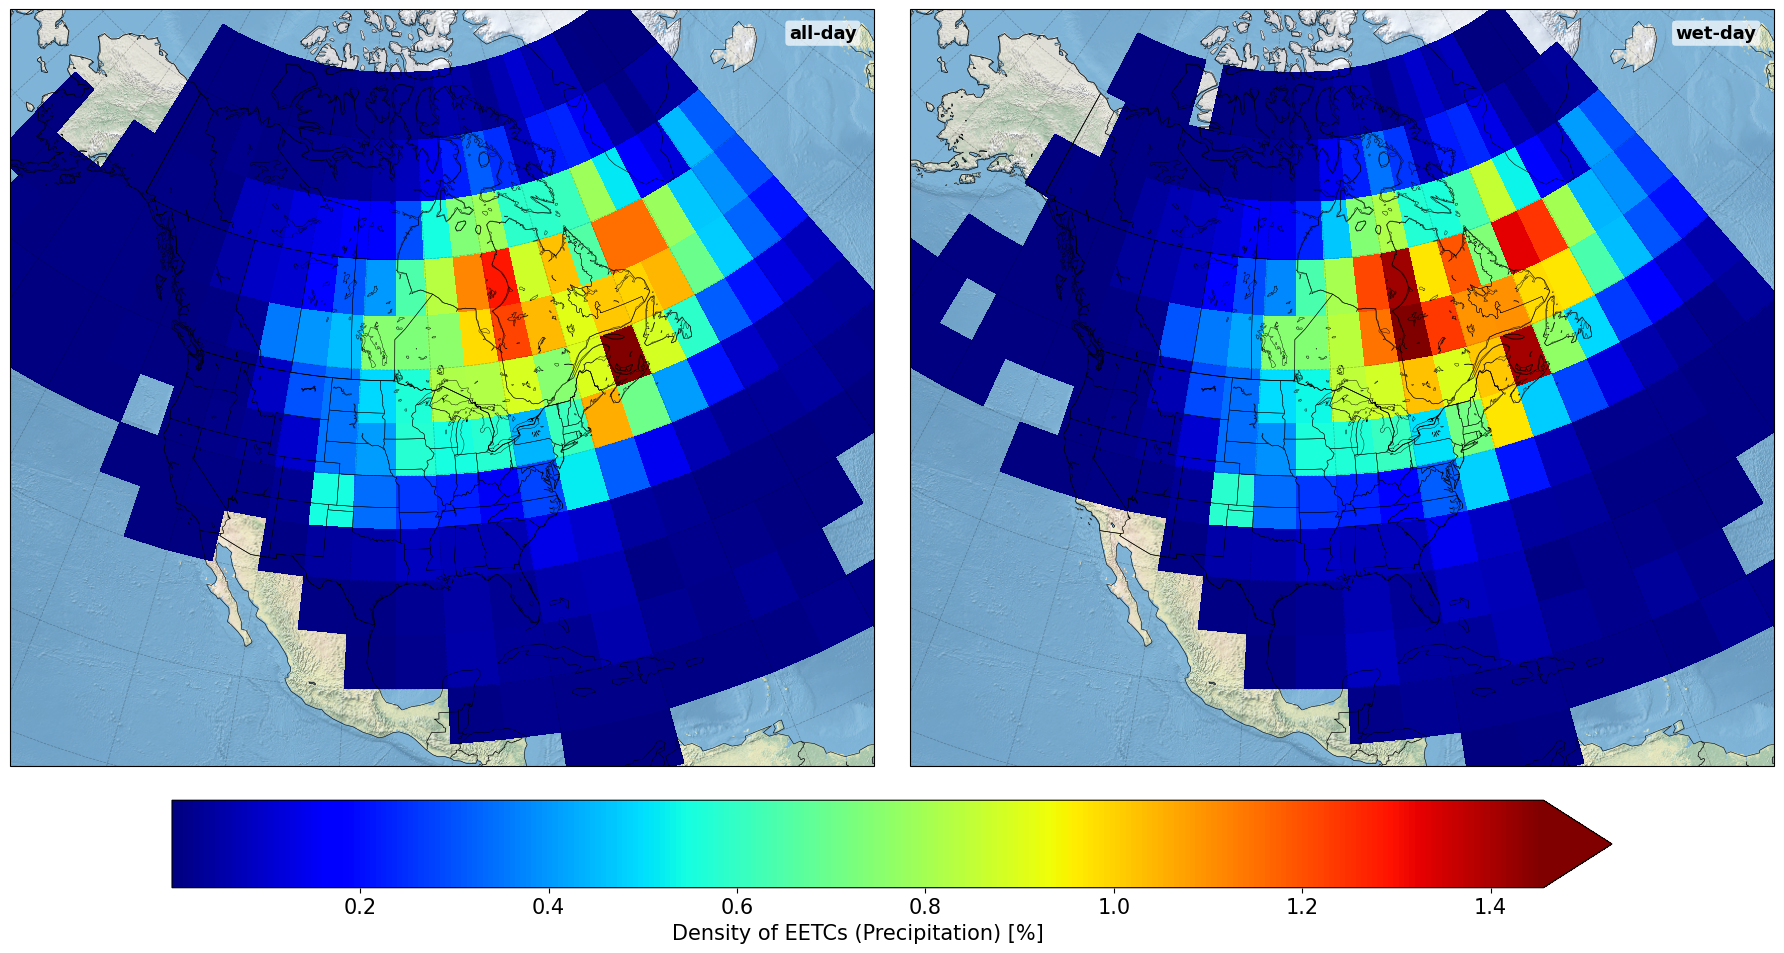

In [59]:
plotcrs = ccrs.LambertConformal(central_latitude=45, central_longitude=-95)
fig = plt.figure(figsize=(18, 25))
axes = [fig.add_axes(pos, projection=plotcrs) for pos in positions]

for i, (ax, sim) in enumerate(zip(axes, ['all-day', 'wet-day'])):
        
    ax.set_extent([-130, -51, 77, 13], crs=ccrs.PlateCarree())

    borders = cartopy.feature.NaturalEarthFeature(category='cultural', name='admin_0_boundary_lines_land', scale='50m', facecolor='none')
    states_provinces = cartopy.feature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces', scale='50m', facecolor='none')
    lakes_color = cartopy.feature.NaturalEarthFeature(category='physical', name='lakes', scale='50m', facecolor='#7FB4D8', edgecolor='black')
    lakes_edge = cartopy.feature.NaturalEarthFeature(category='physical', name='lakes', scale='50m', facecolor='none', edgecolor='black')
    img = plt.imread('/home/vdemeyer/TOOLS/NE1_50M_SR_W.tif')
    ax.add_feature(borders, linewidth=0.5, edgecolor='black', zorder=2)
    ax.add_feature(states_provinces, edgecolor='black', linewidth=0.3)
    ax.add_feature(lakes_color, zorder=1, linewidth=0.3)
    ax.add_feature(lakes_edge, zorder=2, linewidth=0.3)
    ax.coastlines(resolution='10m', linewidth=0.4, color='black')
    ax.gridlines(linewidth=0.5, linestyle='--', color='k', alpha=0.25, xlocs=range(-180,180,10), ylocs=range(-90,90,10))
    ax.imshow(img, origin='upper', extent=(-180, 180, -90, 90), transform=ccrs.PlateCarree())

    vmin = 0
    vmax = 10
    cmap = plt.get_cmap('jet')

    # contrib = (data['total_ETCs_total'][sim] / data['total_total'][sim]) * 100.  #DENSITÉ DE ETCS AVEC PRÉCIPITATION > 0 dans les 1000km du centre
          
    sc = ax.pcolormesh(density_arrays['precip'].lon, density_arrays['precip'].lat,
                       density_arrays['precip'].sel(percentile_type=sim, quantile=0.99).where(density_arrays['precip'].sel(percentile_type=sim, quantile=0.99)>0.),
                       transform=ccrs.PlateCarree(), cmap=cmap, shading='auto')

    ax.text(0.98, 0.98, sim, transform=ax.transAxes, fontsize=13, fontweight='bold',
            ha='right', va='top', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.2'))                    
        
cbar_ax = fig.add_axes([0.14, 0.23, 0.8, 0.035])  # [left, bottom, width, height]    
cbar = fig.colorbar(sc, cax=cbar_ax, orientation="horizontal", pad=0.02, extend='max')
cbar.set_label('Density of EETCs (Precipitation) [%]', fontsize=15)
cbar.ax.tick_params(labelsize=15)

## Contribution of EETCs

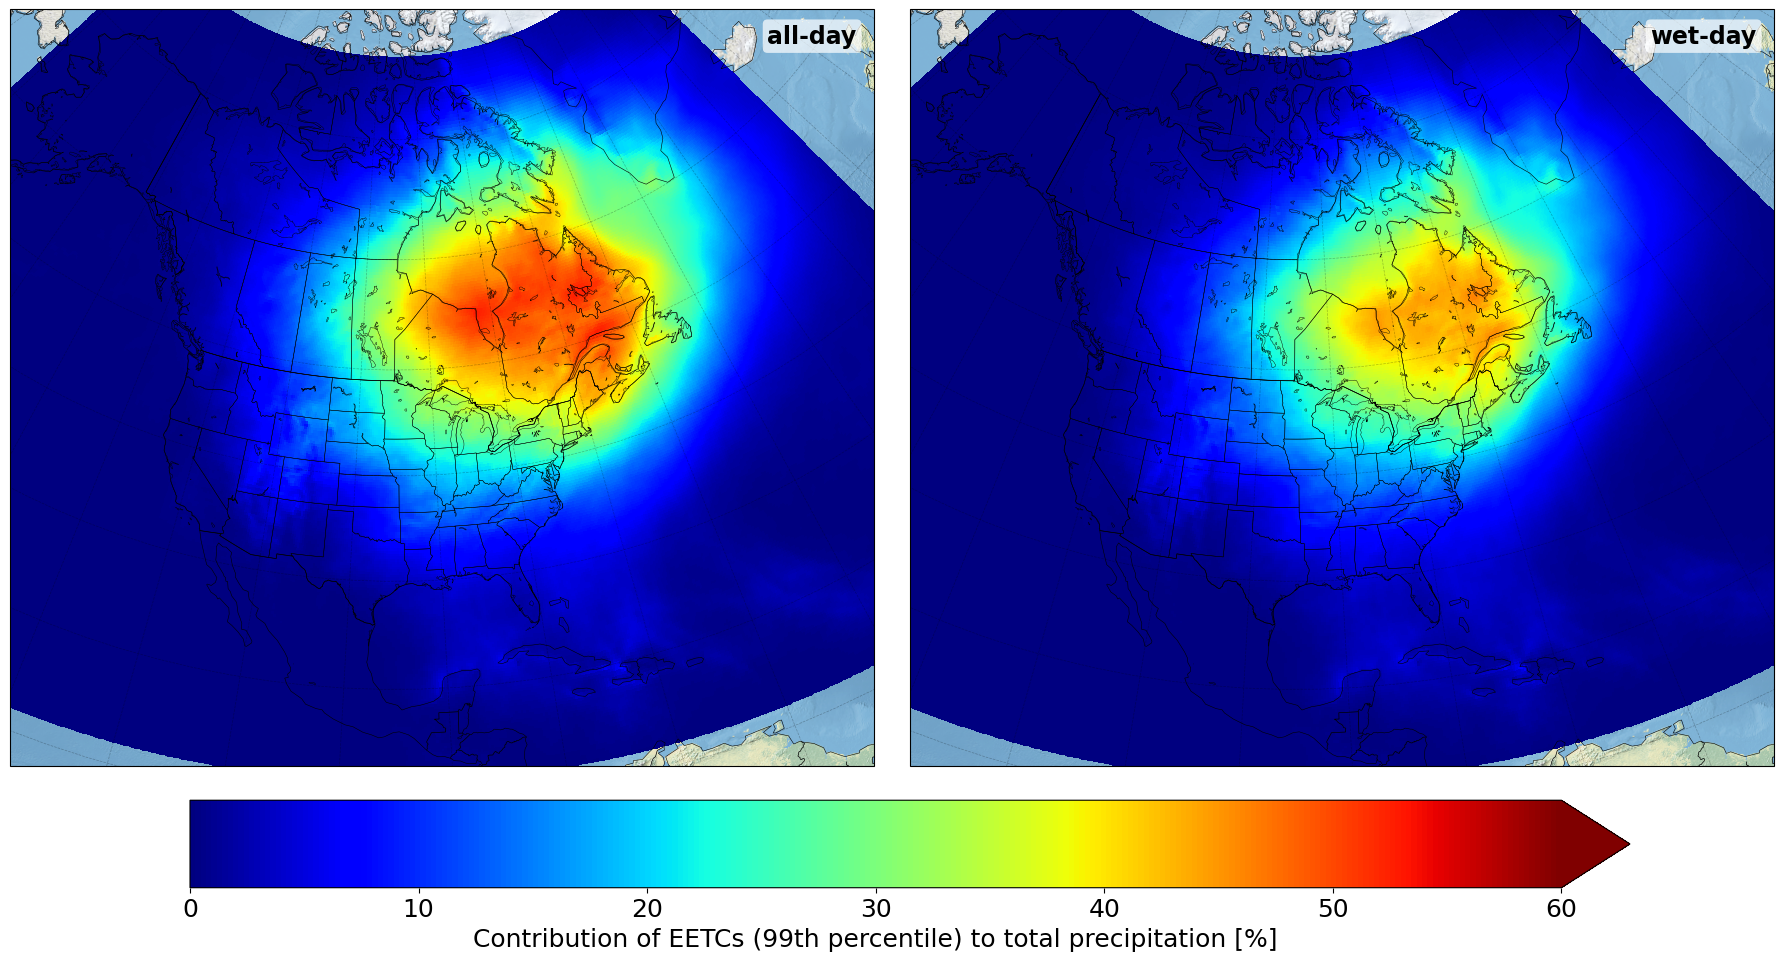

In [21]:
contrib = {sim: (data['total_EETCs_total'][sim].sel(quantile=0.99) / data['total_total'][sim]) * 100. for sim in data['total_total'].keys()}

plot_map(contrib, colormap = 'jet', vmin=0, vmax=60, label='Contribution of EETCs (99th percentile) to total precipitation [%]') 

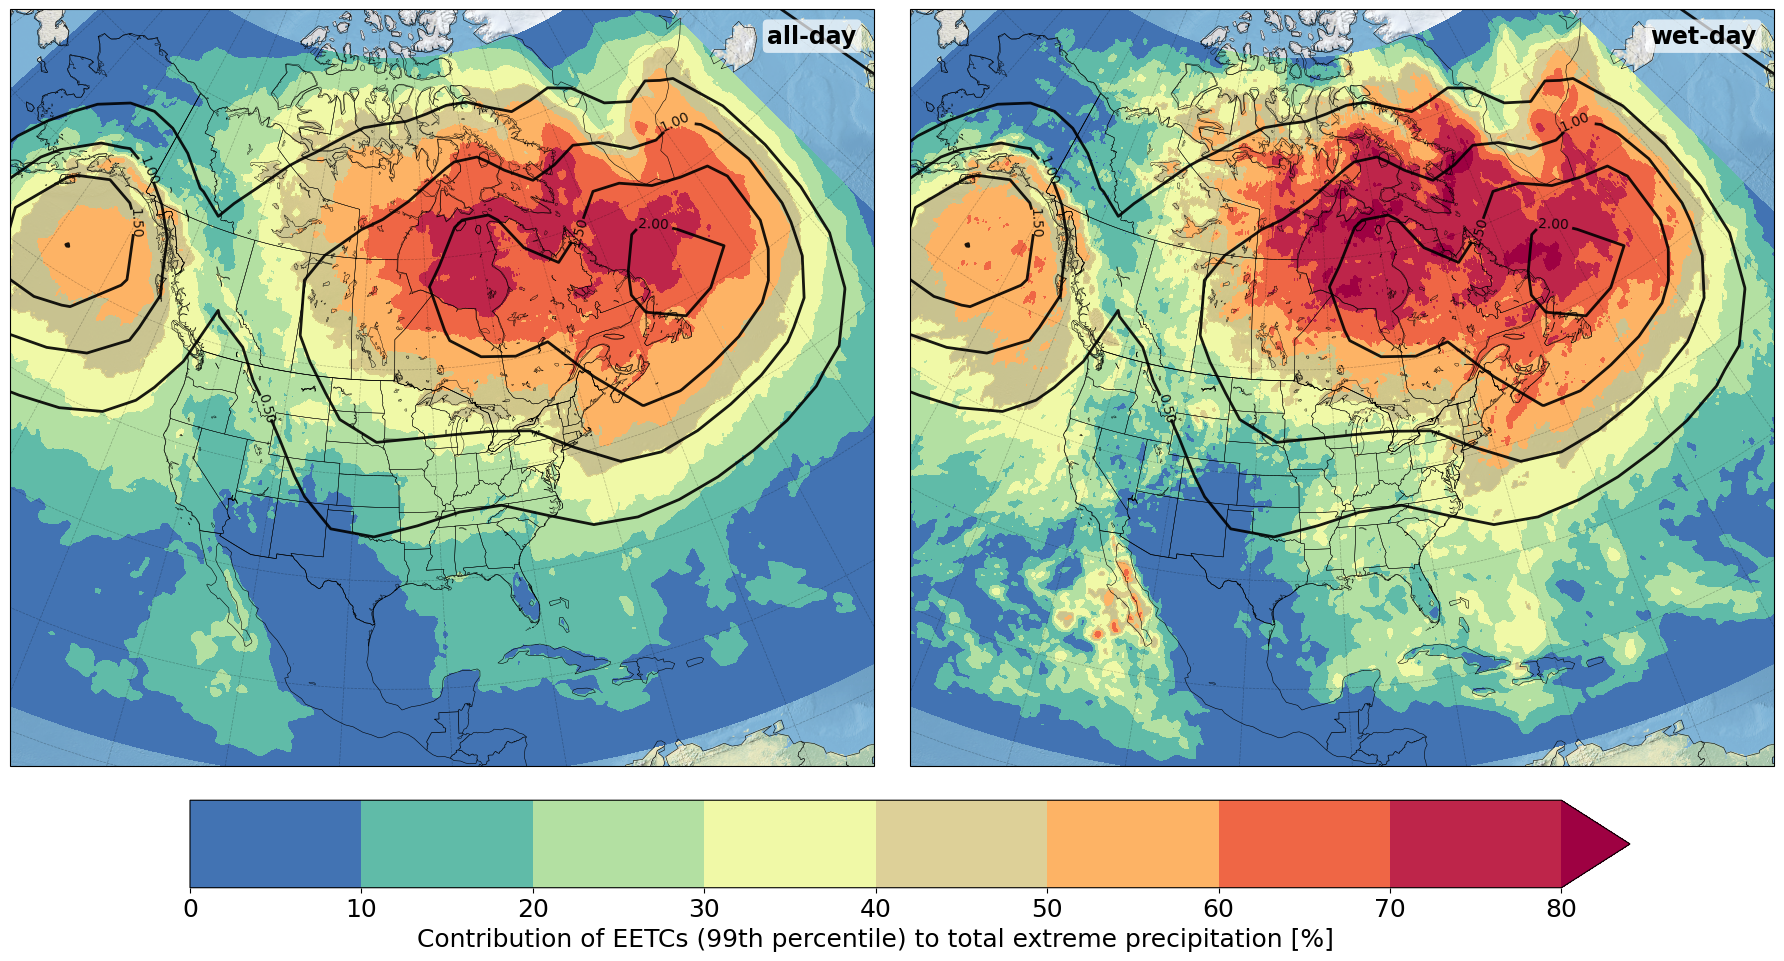

In [19]:
contrib = {
    sim: (
        data['total_ext_EETCs_total'][sim].sel(quantile=0.99) /
        data['total_ext_total'][sim].sel(quantile=0.99,)
    ) * 100.
    for sim in data['total_total'].keys()
}

cont = {
    sim: (
        da_density.where(da_density.sel(percentile_type=sim)>0.).sel(percentile_type=sim)
    )
    for sim in per_type
}
    
plot_map(
    contrib,
    cont = cont,
    contour_levels=np.arange(0, 5, 0.5),
    fmt="%.2f",
    sigma=1,
    colormap='Spectral_r',
    vmin=0,
    vmax=80,
    step=10,
    label='Contribution of EETCs (99th percentile) to total extreme precipitation [%]',
    style='contourf'
)

# plt.savefig(f'/home/vdemeyer/projects/rrg-gachon/vdemeyer/TRACKING/PLOT/contrib_EETCs_to_PR_ext_ETCs_density.png', dpi=120, bbox_inches='tight', transparent=True)

## Intensity metric

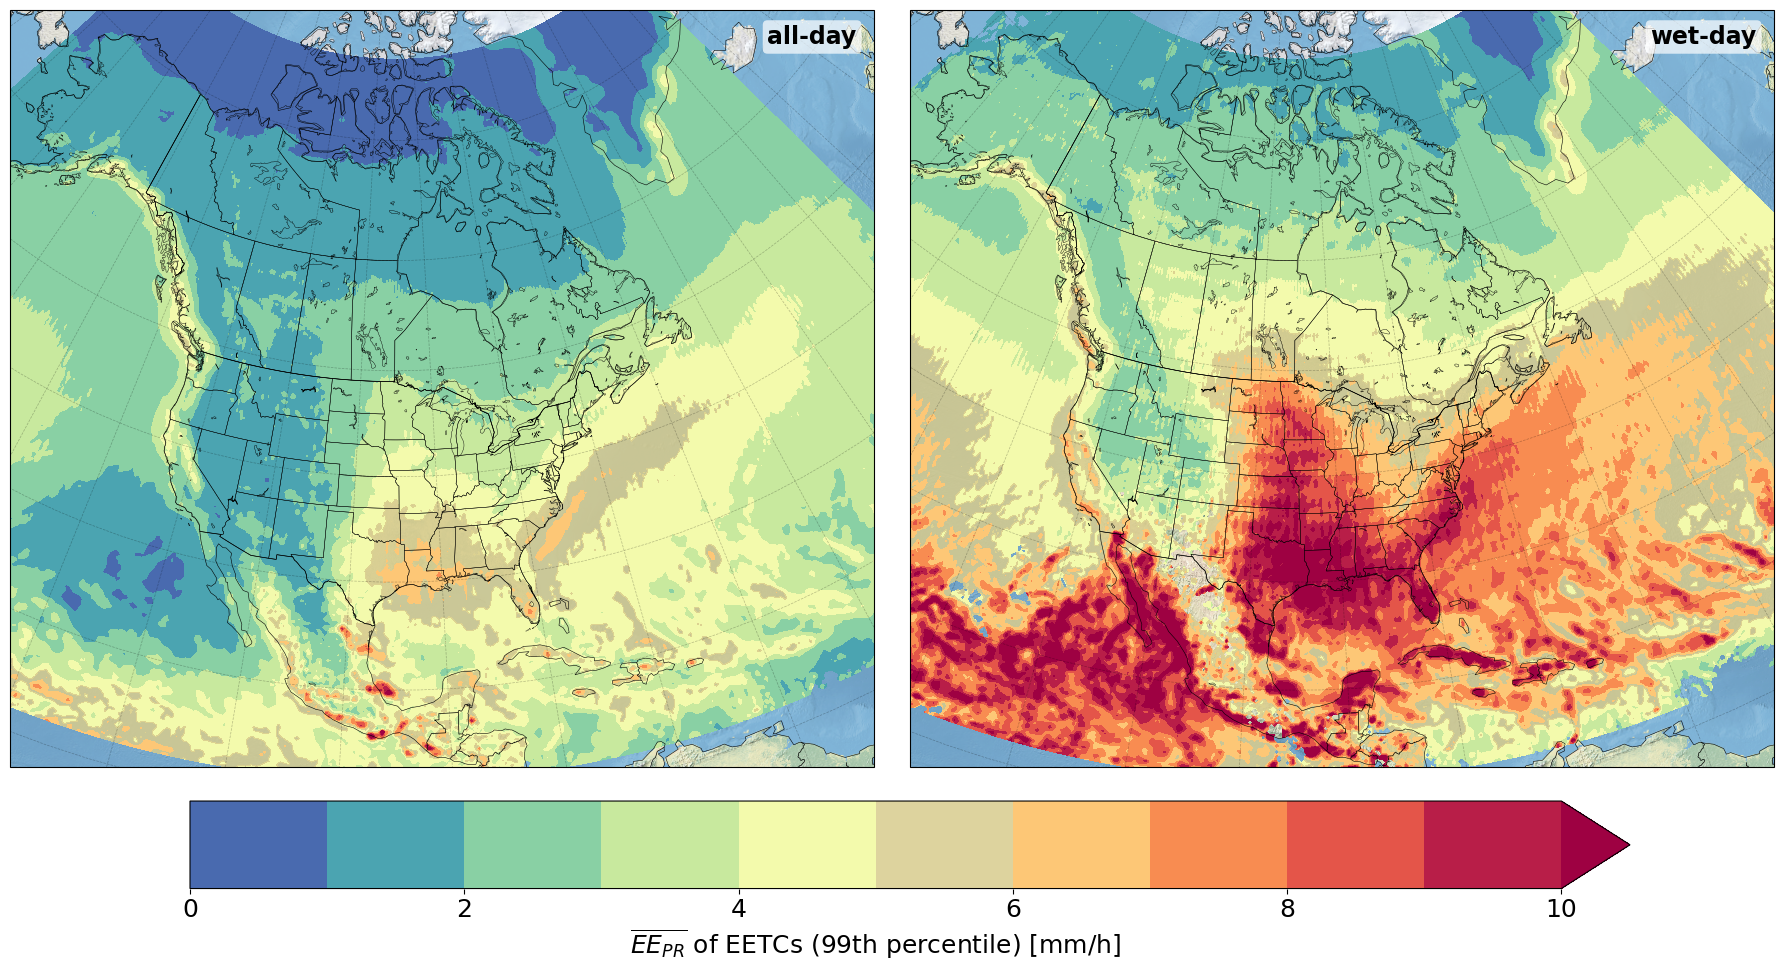

In [25]:
contrib = {
    sim: (
        data['total_ext_EETCs_total'][sim].sel(quantile=0.99) /
        data['count_ext_EETCs_total'][sim].sel(quantile=0.99)
    )
    for sim in data['total_total'].keys()
}

plot_map(
    contrib,
    colormap='Spectral_r',
    vmin=0,
    vmax=10,
    step=1,
    label=r'$\overline{EE_{PR}}$ of EETCs (99th percentile) [mm/h]',
    style='contourf'
)

# plt.savefig(f'/home/vdemeyer/projects/rrg-gachon/vdemeyer/TRACKING/PLOT/EEpr_EETCs.png', dpi=120, bbox_inches='tight', transparent=True)

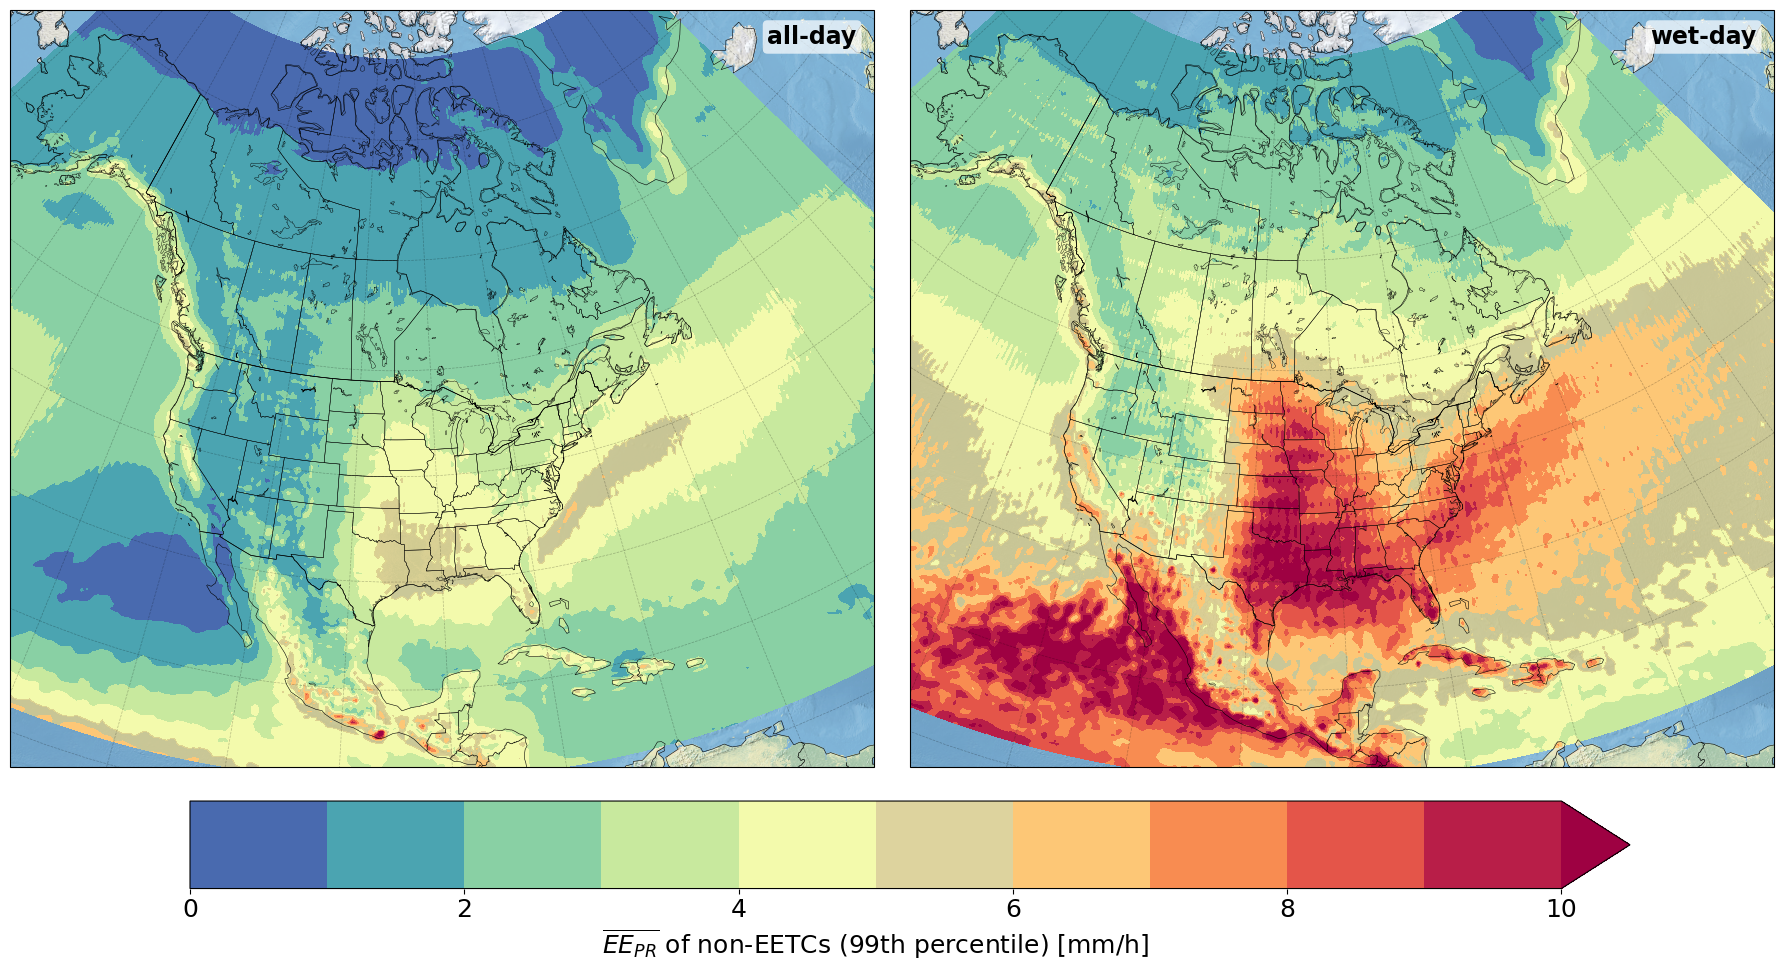

In [26]:
contrib = {
    sim: (
        (data['total_ext_total'][sim].sel(quantile=0.99) - data['total_ext_EETCs_total'][sim].sel(quantile=0.99)) /
        (data['count_ext_total'][sim].sel(quantile=0.99) - data['count_ext_EETCs_total'][sim].sel(quantile=0.99))
    )
    for sim in data['total_total'].keys()
}

plot_map(
    contrib,
    colormap='Spectral_r',
    vmin=0,
    vmax=10,
    step=1,
    label=r'$\overline{EE_{PR}}$ of non-EETCs (99th percentile) [mm/h]',
    style='contourf'
)

# plt.savefig(f'/home/vdemeyer/projects/rrg-gachon/vdemeyer/TRACKING/PLOT/EEpr_nonETCs.png', dpi=120, bbox_inches='tight', transparent=True)

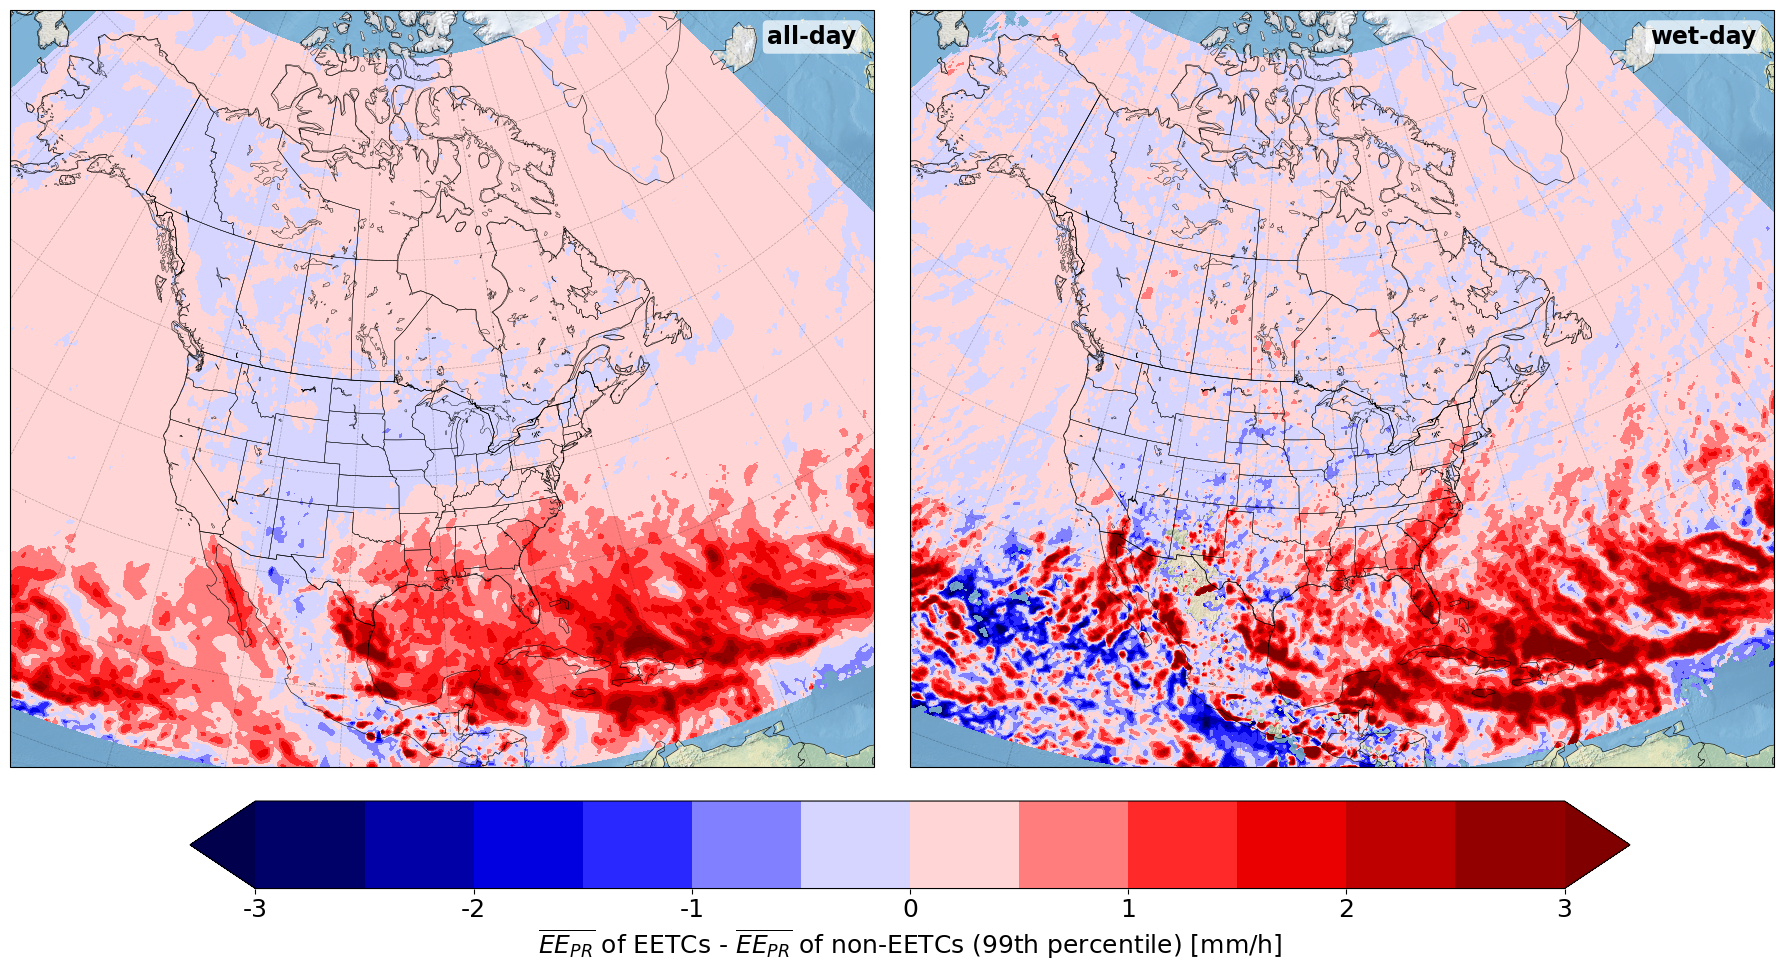

In [29]:
contrib = {
    sim: (
        (
            data['total_ext_EETCs_total'][sim].sel(quantile=0.99) /
            data['count_ext_EETCs_total'][sim].sel(quantile=0.99)
        ) -
        (
            (
                data['total_ext_total'][sim].sel(quantile=0.99) -
                data['total_ext_EETCs_total'][sim].sel(quantile=0.99)
            ) /
            (
                data['count_ext_total'][sim].sel(quantile=0.99) -
                data['count_ext_EETCs_total'][sim].sel(quantile=0.99)
            )
        )
    )
    for sim in data['total_total'].keys()
}


plot_map(
    contrib,
    colormap = 'seismic',
    vmin=-3,
    vmax=3,
    step=0.5,
    label=r'$\overline{EE_{PR}}$ of EETCs - $\overline{EE_{PR}}$ of non-EETCs (99th percentile) [mm/h]',
    bins=13,
    style='contourf'
) 

## Seasonal maps

### ETC contribution

In [ ]:
contrib = {sim: (data['total_ETCs_seasonal'][sim].sel(season='DJF', variable='pr') / data['total_seasonal'][sim].sel(season='DJF', variable='pr')) * 100. for sim in data['total_total'].keys()}

plot_map(contrib, colormap = 'jet', vmin=0, vmax=60, label='Contribution of winter ETCs to total winter precipitation [%]') 

In [ ]:
contrib = {sim: (data['total_ETCs_seasonal'][sim].sel(season='MAM', variable='pr') / data['total_seasonal'][sim].sel(season='MAM', variable='pr')) * 100. for sim in data['total_total'].keys()}

plot_map(contrib, colormap = 'jet', vmin=0, vmax=60, label='Contribution of spring ETCs to total spring precipitation [%]') 

In [ ]:
contrib = {sim: (data['total_ETCs_seasonal'][sim].sel(season='JJA', variable='pr') / data['total_seasonal'][sim].sel(season='JJA', variable='pr')) * 100. for sim in data['total_total'].keys()}

plot_map(contrib, colormap = 'jet', vmin=0, vmax=60, label='Contribution of summer ETCs to total summer precipitation [%]') 

In [ ]:
contrib = {sim: (data['total_ETCs_seasonal'][sim].sel(season='SON', variable='pr') / data['total_seasonal'][sim].sel(season='SON', variable='pr')) * 100. for sim in data['total_total'].keys()}

plot_map(contrib, colormap = 'jet', vmin=0, vmax=60, label='Contribution of fall ETCs to total fall precipitation [%]')

In [ ]:
contrib = {sim: (data['total_ETCs_seasonal'][sim].sel(season='DJF', variable='ws') / data['total_seasonal'][sim].sel(season='DJF', variable='ws')) * 100. for sim in data['total_total'].keys()}

plot_map(contrib, colormap = 'jet', vmin=0, vmax=60, label='Contribution of winter ETCs to total winter wind [%]') 

In [ ]:
contrib = {sim: (data['total_ETCs_seasonal'][sim].sel(season='MAM', variable='ws') / data['total_seasonal'][sim].sel(season='MAM', variable='ws')) * 100. for sim in data['total_total'].keys()}

plot_map(contrib, colormap = 'jet', vmin=0, vmax=60, label='Contribution of spring ETCs to total spring wind [%]') 

In [ ]:
contrib = {sim: (data['total_ETCs_seasonal'][sim].sel(season='JJA', variable='ws') / data['total_seasonal'][sim].sel(season='JJA', variable='ws')) * 100. for sim in data['total_total'].keys()}

plot_map(contrib, colormap = 'jet', vmin=0, vmax=60, label='Contribution of summer ETCs to total summer wind [%]') 

In [ ]:
contrib = {sim: (data['total_ETCs_seasonal'][sim].sel(season='SON', variable='ws') / data['total_seasonal'][sim].sel(season='SON', variable='ws')) * 100. for sim in data['total_total'].keys()}

plot_map(contrib, colormap = 'jet', vmin=0, vmax=60, label='Contribution of fall ETCs to total fall wind [%]') 

### EETCs contribution

In [ ]:
contrib = {
    sim: (
        data['total_ext_EETCs_seasonal'][sim].sel(season='DJF', quantile=0.99, variable='pr') /
        # data['total_ext_total'][sim].sel(quantile=0.99, variable='pr')
        data['total_ext_EETCs_total'][sim].sel(variable='pr', quantile=0.99)
    ) * 100. 
    for sim in data['total_total'].keys()
}

plot_map(
    contrib,
    colormap='Spectral_r',
    vmin=0,
    vmax=70,
    step=10,
    ting=True,
    label='Contribution of winter ETCs to total extreme (>99th percentile) precipitation from ETCs [%]',
    style='contourf'
)

plt.savefig(f'/home/vdemeyer/projects/rrg-gachon/vdemeyer/TRACKING/PLOT/contrib_ETCs_to_PR_ext_winter.png', dpi=120, bbox_inches='tight', transparent=True)

In [ ]:
# contrib = {
#     sim: (
#         data['count_ext_EETCs_seasonal'][sim].sel(season='DJF', quantile=0.99, variable='pr') /
#         data['count_ext_total'][sim].sel(quantile=0.99, variable='pr')
#     ) * 100. 
#     for sim in data['total_total'].keys()
# }

# plot_map(
#     contrib,
#     colormap='Spectral_r',
#     vmin=0,
#     vmax=70,
#     step=10,
#     ting=True,
#     label='Seasonal occurence of ETCs-associated extreme (99th percentile) precipitation event relative to the annual sum of all events [%]',
#     style='contourf'
# )

# plt.savefig(f'/home/vdemeyer/projects/rrg-gachon/vdemeyer/TRACKING/PLOT/occur_ETCs_to_PR_ext_winter.png', dpi=120, bbox_inches='tight', transparent=True)

In [ ]:
contrib = {
    sim: (
        data['total_ext_EETCs_seasonal'][sim].sel(season='MAM', quantile=0.99, variable='pr') /
        # data['total_ext_total'][sim].sel(quantile=0.99, variable='pr')
        data['total_ext_EETCs_total'][sim].sel(variable='pr', quantile=0.99)
    ) * 100. 
    for sim in data['total_total'].keys()
}

plot_map(
    contrib,
    colormap='Spectral_r',
    vmin=0,
    vmax=70,
    step=10,
    ting=True,
    label='Contribution of spring ETCs to total extreme (>99th percentile) precipitation from ETCs [%]',
    style='contourf'
)

plt.savefig(f'/home/vdemeyer/projects/rrg-gachon/vdemeyer/TRACKING/PLOT/contrib_ETCs_to_PR_ext_spring.png', dpi=120, bbox_inches='tight', transparent=True)

In [ ]:
contrib = {
    sim: (
        data['total_ext_EETCs_seasonal'][sim].sel(season='JJA', quantile=0.99, variable='pr') /
        # data['total_ext_total'][sim].sel(quantile=0.99, variable='pr')
        data['total_ext_EETCs_total'][sim].sel(variable='pr', quantile=0.99)
    ) * 100. 
    for sim in data['total_total'].keys()
}

plot_map(
    contrib,
    colormap='Spectral_r',
    vmin=0,
    vmax=70,
    step=10,
    ting=True,
    label='Contribution of summer ETCs to total extreme (>99th percentile) precipitation from ETCs [%]',
    style='contourf'
)

plt.savefig(f'/home/vdemeyer/projects/rrg-gachon/vdemeyer/TRACKING/PLOT/contrib_ETCs_to_PR_ext_summer.png', dpi=120, bbox_inches='tight', transparent=True)

In [ ]:
contrib = {
    sim: (
        data['total_ext_EETCs_seasonal'][sim].sel(season='SON', quantile=0.99, variable='pr') /
        # data['total_ext_total'][sim].sel(quantile=0.99, variable='pr')
        data['total_ext_EETCs_total'][sim].sel(variable='pr', quantile=0.99)
    ) * 100. 
    for sim in data['total_total'].keys()
}

plot_map(
    contrib,
    colormap='Spectral_r',
    vmin=0,
    vmax=70,
    step=10,
    ting=True,
    label='Contribution of fall ETCs to total extreme (>99th percentile) precipitation from ETCs [%]',
    style='contourf'
)

plt.savefig(f'/home/vdemeyer/projects/rrg-gachon/vdemeyer/TRACKING/PLOT/contrib_ETCs_to_PR_ext_fall.png', dpi=120, bbox_inches='tight', transparent=True)

In [ ]:
contrib = {
    sim: (
        data['total_ext_EETCs_seasonal'][sim].sel(season='DJF', quantile=0.99, variable='ws') /
        # data['total_ext_total'][sim].sel(quantile=0.99, variable='ws')
        data['total_ext_EETCs_total'][sim].sel(variable='ws', quantile=0.99)
    ) * 100. 
    for sim in data['total_total'].keys()
}

plot_map(
    contrib,
    colormap='Spectral_r',
    vmin=0,
    vmax=70,
    step=10,
    ting=True,
    label='Contribution of winter ETCs to total extreme (>99th percentile) wind from ETCs [%]',
    style='contourf'
)

plt.savefig(f'/home/vdemeyer/projects/rrg-gachon/vdemeyer/TRACKING/PLOT/contrib_ETCs_to_WS_ext_winter.png', dpi=120, bbox_inches='tight', transparent=True)

In [ ]:
contrib = {
    sim: (
        data['total_ext_EETCs_seasonal'][sim].sel(season='MAM', quantile=0.99, variable='ws') /
        # data['total_ext_total'][sim].sel(quantile=0.99, variable='ws')
        data['total_ext_EETCs_total'][sim].sel(variable='ws', quantile=0.99)
    ) * 100. 
    for sim in data['total_total'].keys()
}

plot_map(
    contrib,
    colormap='Spectral_r',
    vmin=0,
    vmax=70,
    step=10,
    ting=True,
    label='Contribution of spring ETCs to total extreme (>99th percentile) wind from ETCs [%]',
    style='contourf'
)

plt.savefig(f'/home/vdemeyer/projects/rrg-gachon/vdemeyer/TRACKING/PLOT/contrib_ETCs_to_WS_ext_spring.png', dpi=120, bbox_inches='tight', transparent=True)

In [ ]:
contrib = {
    sim: (
        data['total_ext_EETCs_seasonal'][sim].sel(season='JJA', quantile=0.99, variable='ws') /
        # data['total_ext_total'][sim].sel(quantile=0.99, variable='ws')
        data['total_ext_EETCs_total'][sim].sel(variable='ws', quantile=0.99)
    ) * 100. 
    for sim in data['total_total'].keys()
}

plot_map(
    contrib,
    colormap='Spectral_r',
    vmin=0,
    vmax=70,
    step=10,
    ting=True,
    label='Contribution of summer ETCs to total extreme (>99th percentile) wind from ETCs [%]',
    style='contourf'
)

plt.savefig(f'/home/vdemeyer/projects/rrg-gachon/vdemeyer/TRACKING/PLOT/contrib_ETCs_to_WS_ext_summer.png', dpi=120, bbox_inches='tight', transparent=True)

In [ ]:
contrib = {
    sim: (
        data['total_ext_EETCs_seasonal'][sim].sel(season='SON', quantile=0.99, variable='ws') /
        # data['total_ext_total'][sim].sel(quantile=0.99, variable='ws')
        data['total_ext_EETCs_total'][sim].sel(variable='ws', quantile=0.99)
    ) * 100. 
    for sim in data['total_total'].keys()
}

plot_map(
    contrib,
    colormap='Spectral_r',
    vmin=0,
    vmax=70,
    step=10,
    ting=True,
    label='Contribution of fall ETCs to total extreme (>99th percentile) wind from ETCs [%]',
    style='contourf'
)

plt.savefig(f'/home/vdemeyer/projects/rrg-gachon/vdemeyer/TRACKING/PLOT/contrib_ETCs_to_WS_ext_fall.png', dpi=120, bbox_inches='tight', transparent=True)

## For testing the template

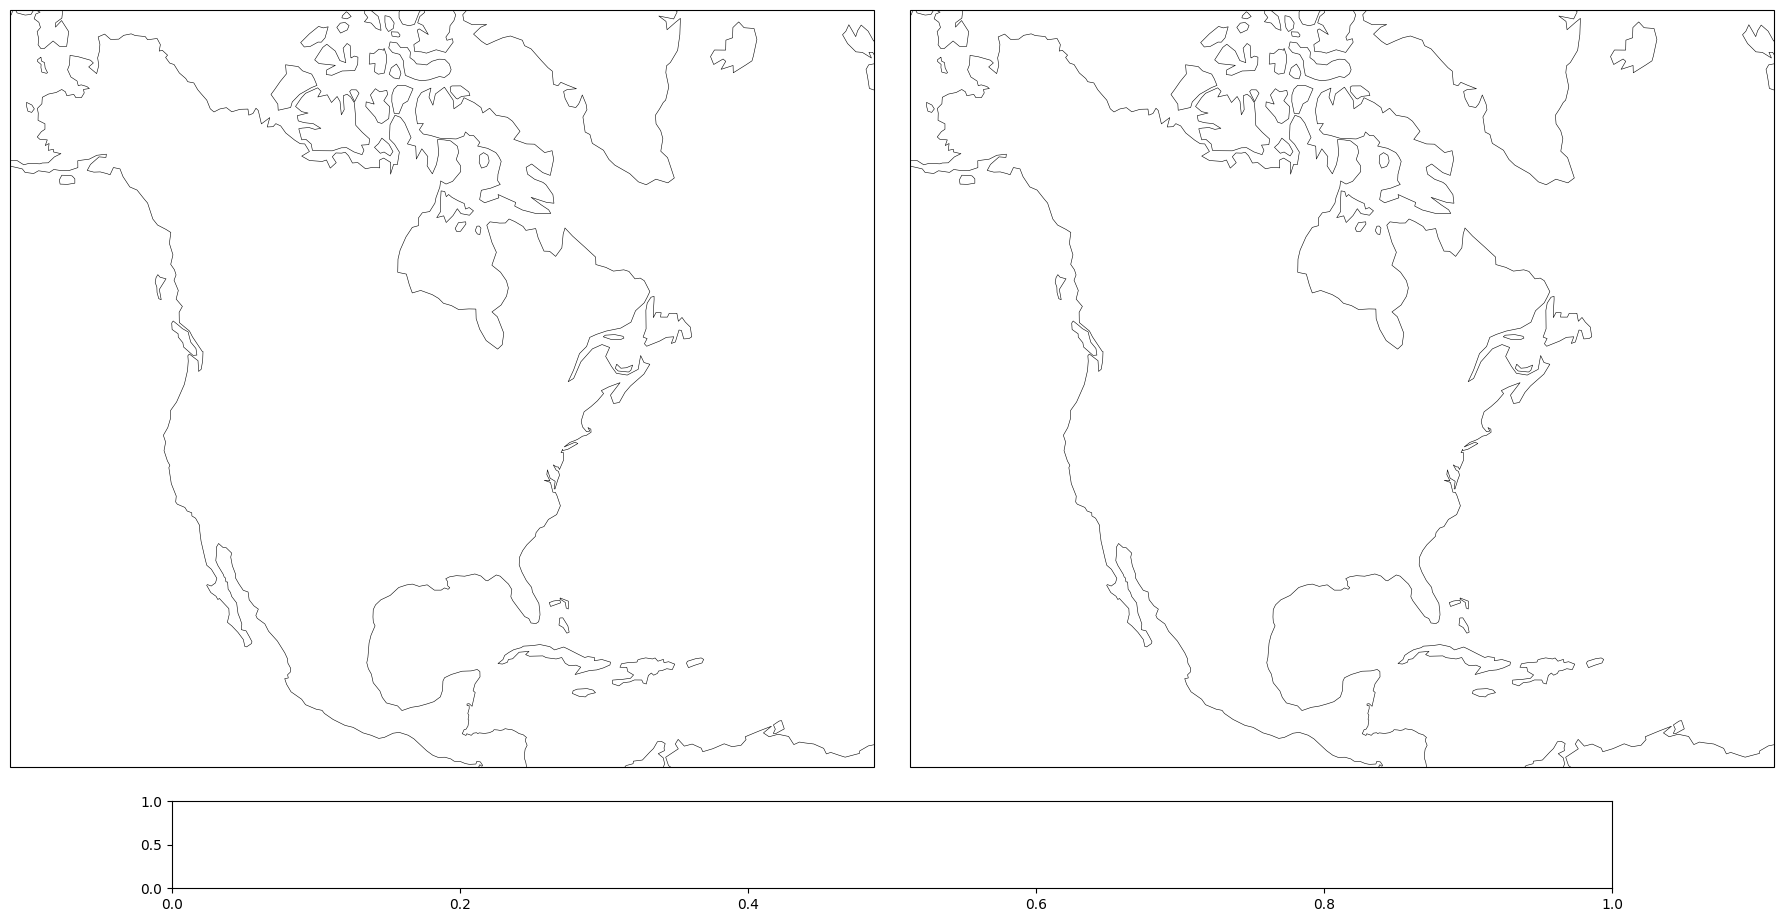

In [58]:
plotcrs = ccrs.LambertConformal(central_latitude=45, central_longitude=-95)
fig = plt.figure(figsize=(18, 25))
positions = [
    [0.05, 0.18, 0.48, 0.50],  # Rangée du haut, Colonne 1
    [0.55, 0.18, 0.48, 0.50],  # Rangée du haut, Colonne 2
]

axes = [fig.add_axes(pos, projection=plotcrs) for pos in positions]

for i, ax in enumerate(axes):

    ax.set_extent([-130, -51, 77, 13], crs=ccrs.PlateCarree())

    ax.coastlines(resolution='10m', linewidth=0.4, color='black')

cbar_ax = fig.add_axes([0.14, 0.23, 0.8, 0.035])  # [left, bottom, width, height]
# cbar = fig.colorbar(sc, cax=cbar_ax, orientation="horizontal", pad=0.02)
# cbar.set_label('Precipitation exceedance (mm)', fontsize=15)
# cbar.ax.tick_params(labelsize=15)